## Normalization

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plot

from sklearn.model_selection import train_test_split

df = pd.read_csv("../../train.csv")

df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
552,553,0,3,"O'Brien, Mr. Timothy",male,NaN,0,0,330979,7.8292,NaN,Q
219,220,0,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.5000,NaN,S
401,402,0,3,"Adams, Mr. John",male,26.0,0,0,341826,8.0500,NaN,S


In [12]:
#build a new df
newds = pd.DataFrame({
  "Survived" : df["Survived"],
  "Pclass" : df["Pclass"],
  "Fare" : df["Fare"]
})

newds.sample(3)

,Survived,Pclass,Fare
441,0,3,9.5
219,0,2,10.5
35,0,1,52.0


In [13]:
X = newds.iloc[:, 1:] #row, col
Y = newds.iloc[:,:1]

X_train: pd.DataFrame #input is df
X_test: pd.DataFrame
Y_train: pd.Series #op is row
Y_test: pd.Series

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=45)

print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(596, 2) (295, 2) (596, 1) (295, 1)


### MinMax scaling

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test.describe(), X_test_scaled_df.describe()


(           Pclass        Fare
 count  295.000000  295.000000
 mean     2.362712   29.476188
 std      0.808521   45.586869
 min      1.000000    0.000000
 25%      2.000000    7.895800
 50%      3.000000   13.000000
 75%      3.000000   30.000000
 max      3.000000  512.329200,
            Pclass        Fare
 count  295.000000  295.000000
 mean     0.681356    0.057534
 std      0.404261    0.088980
 min      0.000000    0.000000
 25%      0.500000    0.015412
 50%      1.000000    0.025374
 75%      1.000000    0.058556
 max      1.000000    1.000000)

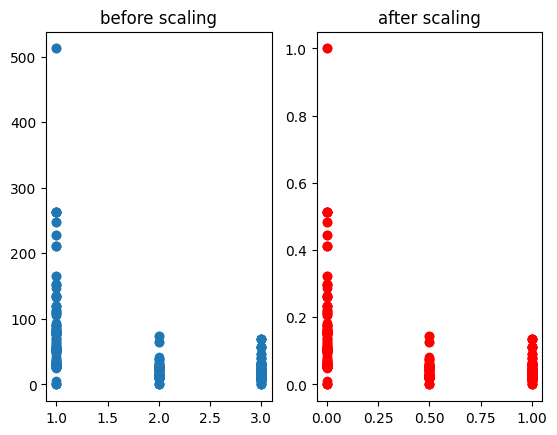

In [15]:
g1 : plot
g2 : plot
fig, (g1, g2) = plot.subplots(ncols = 2) 
#g1 - first graph
#g2 - second graph so ncols = 2

g1.scatter(x=X_train["Pclass"], y=X_train["Fare"])
g1.set_title("before scaling")
g2.scatter(x=X_train_scaled_df["Pclass"], y=X_train_scaled_df["Fare"], color="red")
g2.set_title("after scaling")
plot.show()

### Max Absolute Scaler

In [16]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()

scaler.fit(X_train)

X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

np.round(X_test.describe()), np.round(X_test_scaled_df.describe())

(       Pclass   Fare
 count   295.0  295.0
 mean      2.0   29.0
 std       1.0   46.0
 min       1.0    0.0
 25%       2.0    8.0
 50%       3.0   13.0
 75%       3.0   30.0
 max       3.0  512.0,
        Pclass   Fare
 count   295.0  295.0
 mean      1.0    0.0
 std       0.0    0.0
 min       0.0    0.0
 25%       1.0    0.0
 50%       1.0    0.0
 75%       1.0    0.0
 max       1.0    1.0)

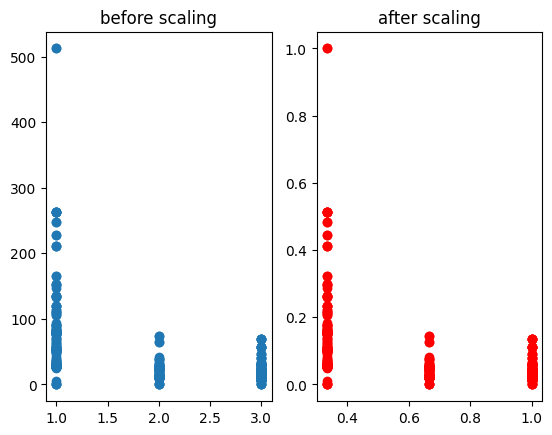

In [17]:
g1 : plot
g2 : plot
fig, (g1, g2) = plot.subplots(ncols = 2) 
#g1 - first graph
#g2 - second graph so ncols = 2

g1.scatter(x=X_train["Pclass"], y=X_train["Fare"])
g1.set_title("before scaling")
g2.scatter(x=X_train_scaled_df["Pclass"], y=X_train_scaled_df["Fare"], color="red")
g2.set_title("after scaling")
plot.show()

### Robust Scaling

In [18]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

scaler.fit(X_train)

X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

np.round(X_test.describe()), np.round(X_test_scaled_df.describe())

(       Pclass   Fare
 count   295.0  295.0
 mean      2.0   29.0
 std       1.0   46.0
 min       1.0    0.0
 25%       2.0    8.0
 50%       3.0   13.0
 75%       3.0   30.0
 max       3.0  512.0,
        Pclass   Fare
 count   295.0  295.0
 mean     -1.0    1.0
 std       1.0    2.0
 min      -2.0   -1.0
 25%      -1.0   -0.0
 50%       0.0    0.0
 75%       0.0    1.0
 max       0.0   23.0)

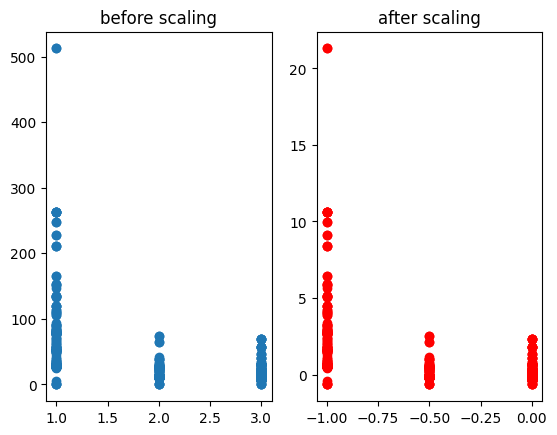

In [19]:
g1 : plot
g2 : plot
fig, (g1, g2) = plot.subplots(ncols = 2) 
#g1 - first graph
#g2 - second graph so ncols = 2

g1.scatter(x=X_train["Pclass"], y=X_train["Fare"])
g1.set_title("before scaling")
g2.scatter(x=X_train_scaled_df["Pclass"], y=X_train_scaled_df["Fare"], color="red")
g2.set_title("after scaling")
plot.show()